In [1]:
# ============================================
# 1. Imports
# ============================================
import re
import os
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sentence_transformers import SentenceTransformer

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

In [2]:
# ============================================
# 2. Configuration
# ============================================
DATASET_NAME = os.path.abspath("../dataset/text_only")
DATASET_SPLIT = "train"
TEXT_COL = "text"

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

# Preprocessing
REMOVE_URLS = True
REMOVE_MENTIONS = True
NORMALIZE_WHITESPACE = True
LOWERCASE = True
REMOVE_RT = True
KEEP_HASHTAG_TEXT = True
REMOVE_EMOJIS = False
REMOVE_DUPLICATES = True
MIN_CHARS = 3

# Embedding / batching
BATCH_SIZE = 128
SHOW_PROGRESS_BAR = True

# Agglomerative clustering setup
K_RANGE = range(2, 60)
RANDOM_STATE = 42

# Recommended default for sentence embeddings
AGGLO_LINKAGE = "average"      # options: "ward", "complete", "average", "single"
AGGLO_METRIC = "cosine"        # "cosine" works with average/complete/single, not with ward

# Optional dimensionality reduction before clustering
USE_PCA_BEFORE_CLUSTERING = False
PCA_DIM = 50

# Inspection
N_REPRESENTATIVE_TWEETS = 10
TOP_TERMS_PER_CLUSTER = 15
TOP_NGRAM_RANGE = (1, 2)
TOP_TERMS_MAX_FEATURES = 5000

# Visualization
VIS_SAMPLE_SIZE = 3000

In [3]:
# ============================================
# 3. Load dataset
# ============================================
# Example 1: loading a named HF dataset
# dataset = load_dataset(DATASET_NAME)

# Example 2: loading a local dataset from disk
from datasets import load_from_disk
# dataset = load_from_disk(DATASET_NAME)

# Replace this section based on your actual setup:
dataset = load_from_disk(DATASET_NAME)

# If dataset is a DatasetDict, select split
hf_split = dataset[DATASET_SPLIT]
orig_size = hf_split.num_rows

print(hf_split)
print(hf_split.column_names)
print(f"Original size: {orig_size}")

Dataset({
    features: ['textID', 'text'],
    num_rows: 24732
})
['textID', 'text']
Original size: 24732


In [4]:
# ============================================
# 4. Preprocessing functions
# ============================================
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
RT_PATTERN = re.compile(r"^rt\s+", re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def preprocess_tweet(text: str) -> str:
    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)

    if LOWERCASE:
        text = text.lower()

    if REMOVE_RT:
        text = RT_PATTERN.sub("", text)

    if REMOVE_URLS:
        text = URL_PATTERN.sub(" ", text)

    if REMOVE_MENTIONS:
        text = MENTION_PATTERN.sub(" ", text)

    if KEEP_HASHTAG_TEXT:
        text = HASHTAG_PATTERN.sub(r"\1", text)
    else:
        text = HASHTAG_PATTERN.sub(" ", text)

    if REMOVE_EMOJIS:
        text = EMOJI_PATTERN.sub(" ", text)

    if NORMALIZE_WHITESPACE:
        text = WHITESPACE_PATTERN.sub(" ", text).strip()

    return text

In [5]:
# ============================================
# 5. Convert HF dataset to DataFrame and clean
# ============================================
df = hf_split.to_pandas()

assert TEXT_COL in df.columns, f"Column '{TEXT_COL}' not found in dataset."

df = df[[TEXT_COL]].copy()
df["raw_text"] = df[TEXT_COL].astype(str)
df["clean_text"] = df["raw_text"].apply(preprocess_tweet)

df = df[df["clean_text"].str.len() >= MIN_CHARS].copy()

if REMOVE_DUPLICATES:
    df = df.drop_duplicates(subset=["clean_text"]).copy()

df = df.reset_index(drop=True)

print(f"Number of usable tweets: {len(df)}")
df.head()

Number of usable tweets: 24655


,text,raw_text,clean_text
0,Craziier are off of msn!,Craziier are off of msn!,craziier are off of msn!
1,"Sadly, all I have is the Stanley Steemer 800 ...","Sadly, all I have is the Stanley Steemer 800 ...","sadly, all i have is the stanley steemer 800 n..."
2,Ahhhh!!!!!! Almost off!!! Can`t wait!! But..I ...,Ahhhh!!!!!! Almost off!!! Can`t wait!! But..I ...,ahhhh!!!!!! almost off!!! can`t wait!! but..i ...
3,500! updates! wooow!! haha!!,500! updates! wooow!! haha!!,500! updates! wooow!! haha!!
4,"Nothing like 10P to kick-off the Bank Holiday,...","Nothing like 10P to kick-off the Bank Holiday,...","nothing like 10p to kick-off the bank holiday,..."


In [6]:
# ============================================
# 6. Load sentence embedding model
# ============================================
model = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
# ============================================
# 7. Generate sentence embeddings
# ============================================
texts = df["clean_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BAR,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/193 [00:00<?, ?it/s]

Embeddings shape: (24655, 384)


In [8]:
# ============================================
# 8. Optional PCA before clustering
# ============================================
X = embeddings

if USE_PCA_BEFORE_CLUSTERING:
    pca = PCA(n_components=PCA_DIM, random_state=RANDOM_STATE)
    X = pca.fit_transform(X)
    print("Reduced shape after PCA:", X.shape)

In [9]:
# ============================================
# 9. Evaluate different k values using silhouette
# ============================================
def evaluate_agglomerative_k(X, k_range, linkage="average", metric="cosine"):
    rows = []

    for k in k_range:
        print(f"Evaluating k={k}...")

        clusterer = AgglomerativeClustering(
            n_clusters=k,
            metric=metric,
            linkage=linkage
        )

        labels = clusterer.fit_predict(X)
        sil = silhouette_score(X, labels, metric=metric)

        rows.append({
            "k": k,
            "silhouette": sil
        })

    return pd.DataFrame(rows)


results_df = evaluate_agglomerative_k(
    X,
    k_range=K_RANGE,
    linkage=AGGLO_LINKAGE,
    metric=AGGLO_METRIC
)

results_df

Evaluating k=2...
Evaluating k=3...
Evaluating k=4...
Evaluating k=5...
Evaluating k=6...
Evaluating k=7...
Evaluating k=8...
Evaluating k=9...
Evaluating k=10...
Evaluating k=11...
Evaluating k=12...
Evaluating k=13...
Evaluating k=14...
Evaluating k=15...
Evaluating k=16...
Evaluating k=17...
Evaluating k=18...
Evaluating k=19...
Evaluating k=20...
Evaluating k=21...
Evaluating k=22...
Evaluating k=23...
Evaluating k=24...
Evaluating k=25...
Evaluating k=26...
Evaluating k=27...
Evaluating k=28...
Evaluating k=29...
Evaluating k=30...
Evaluating k=31...
Evaluating k=32...
Evaluating k=33...
Evaluating k=34...
Evaluating k=35...
Evaluating k=36...
Evaluating k=37...
Evaluating k=38...
Evaluating k=39...
Evaluating k=40...
Evaluating k=41...
Evaluating k=42...
Evaluating k=43...
Evaluating k=44...
Evaluating k=45...
Evaluating k=46...
Evaluating k=47...
Evaluating k=48...
Evaluating k=49...
Evaluating k=50...
Evaluating k=51...
Evaluating k=52...
Evaluating k=53...
Evaluating k=54...
E

,k,silhouette
0,2,0.106110
1,3,0.089314
2,4,0.079802
3,5,0.072312
4,6,0.066439
5,7,0.057948
6,8,0.041283
7,9,0.038596
8,10,0.033966
9,11,0.019135


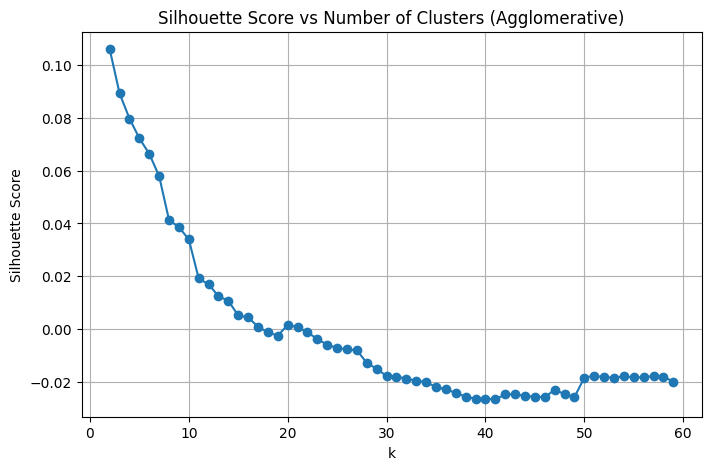

Best k by silhouette score: 2


In [10]:
# ============================================
# 10. Plot silhouette scores
# ============================================
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["silhouette"], marker="o")
plt.title("Silhouette Score vs Number of Clusters (Agglomerative)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])
print("Best k by silhouette score:", best_k)

In [11]:
# ============================================
# 11. Fit final Agglomerative Clustering
# ============================================
FINAL_K = best_k   # or manually override

clusterer = AgglomerativeClustering(
    n_clusters=FINAL_K,
    metric=AGGLO_METRIC,
    linkage=AGGLO_LINKAGE
)

df["cluster"] = clusterer.fit_predict(X).astype(int)

print(df["cluster"].value_counts().sort_index())

cluster
0    24641
1       14
Name: count, dtype: int64


In [12]:
# ============================================
# 12. Representative tweets per cluster
# ============================================
def get_cluster_centers_from_mean(X, labels):
    """
    Compute pseudo-centers by averaging vectors within each cluster.
    """
    centers = {}
    unique_labels = sorted(np.unique(labels))

    for cluster_id in unique_labels:
        cluster_vectors = X[labels == cluster_id]
        centers[cluster_id] = cluster_vectors.mean(axis=0)

    return centers


def get_representative_tweets_agglomerative(df, X, labels, n=10, metric="cosine"):
    """
    Return tweets closest to the mean vector of each cluster.
    """
    centers = get_cluster_centers_from_mean(X, labels)
    cluster_to_examples = {}

    for cluster_id in sorted(np.unique(labels)):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_vectors = X[cluster_indices]
        center = centers[cluster_id].reshape(1, -1)

        if metric == "cosine":
            distances = cosine_distances(cluster_vectors, center).ravel()
        else:
            distances = euclidean_distances(cluster_vectors, center).ravel()

        nearest_local_idx = np.argsort(distances)[:n]
        nearest_global_idx = cluster_indices[nearest_local_idx]

        cluster_to_examples[cluster_id] = df.iloc[nearest_global_idx][
            ["raw_text", "clean_text", "cluster"]
        ].copy()

    return cluster_to_examples


labels = df["cluster"].values

rep_examples = get_representative_tweets_agglomerative(
    df=df,
    X=X,
    labels=labels,
    n=N_REPRESENTATIVE_TWEETS,
    metric=AGGLO_METRIC
)

for cluster_id, cluster_df in rep_examples.items():
    print("=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)
    for _, row in cluster_df.iterrows():
        print("-", row["raw_text"])
    print()

CLUSTER 0
- iÃ¯Â¿Â½m boring - bad weather today, watchingn alias and having fun  with my boyfriend
- just got home from a meeting with the girls... Maaaaaan I`m exhausted!! Goodnight world
- just woke up..busy busy busy 2day...bake bbyshower cupcakes and jays bday cake, bleach hair again & see my boo
- Doesnt feel good!  but I cant miss work tomorrow!
- need to cheer up!
- Omg soo tired! On my way home! Long busy day ; had fun meeting new people and catching up with some people!
- wanted to go to the club...dancing;)..but now iÃ¯Â¿Â½m tired anyways i have to go to work tomorrow!
- Coming to the end of a looooong day. Good new is, I got everything done! Bad news- I gotta wake up @ 4:45am tomorrow for work!
- Yayz! Today`s is the day I call and see if I got that job! x3 I ish so happy... even though I slept horribly... So I`m kinda drained...
- Fml! Ughhhhhhhhh, im not going anwhere today just sit in the bedroom I share with my mother and cry!

CLUSTER 1
-  Thanks for the tip on otherinb

In [13]:
# ============================================
# 13. Top terms per cluster
# ============================================
def extract_top_terms_per_cluster(
    df,
    text_col="clean_text",
    cluster_col="cluster",
    top_n=15,
    ngram_range=(1, 2),
    max_features=5000
):
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        max_features=max_features
    )

    X_bow = vectorizer.fit_transform(df[text_col])
    vocab = np.array(vectorizer.get_feature_names_out())

    cluster_top_terms = {}

    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_mask = (df[cluster_col].values == cluster_id)
        cluster_matrix = X_bow[cluster_mask]

        mean_counts = np.asarray(cluster_matrix.mean(axis=0)).ravel()
        top_idx = np.argsort(mean_counts)[::-1][:top_n]
        cluster_top_terms[cluster_id] = vocab[top_idx].tolist()

    return cluster_top_terms


top_terms = extract_top_terms_per_cluster(
    df,
    text_col="clean_text",
    cluster_col="cluster",
    top_n=TOP_TERMS_PER_CLUSTER,
    ngram_range=TOP_NGRAM_RANGE,
    max_features=TOP_TERMS_MAX_FEATURES
)

for cluster_id, terms in top_terms.items():
    print(f"Cluster {cluster_id}: {terms}")

Cluster 0: ['just', 'day', 'good', 'like', 'work', 'love', 'today', 'going', 'got', 'lol', 'happy', 'time', 'know', 'really', 'don']
Cluster 1: ['outlook', 'word', 'office', 'open', 'use', 'need', 'ms', 'work', 'thanks', 'help', 'just', 'iphone', 'exchange', 'taking', 'won work']


In [14]:
# ============================================
# 14. Cluster summary table
# ============================================
summary_rows = []

for cluster_id in sorted(df["cluster"].unique()):
    cluster_size = (df["cluster"] == cluster_id).sum()
    terms = ", ".join(top_terms[cluster_id][:10])

    summary_rows.append({
        "cluster": cluster_id,
        "size": cluster_size,
        "top_terms": terms
    })

summary_df = pd.DataFrame(summary_rows).sort_values("size", ascending=False)
summary_df

,cluster,size,top_terms
0,0,24641,"just, day, good, like, work, love, today, goin..."
1,1,14,"outlook, word, office, open, use, need, ms, wo..."


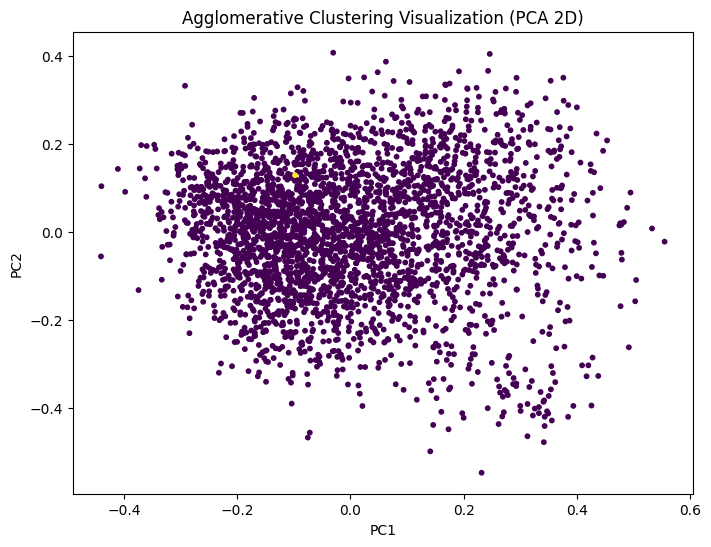

In [15]:
# ============================================
# 15. Optional 2D visualization
# ============================================
plot_df = df.copy()
plot_X = X.copy()

if len(plot_df) > VIS_SAMPLE_SIZE:
    sampled_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(plot_df), size=VIS_SAMPLE_SIZE, replace=False
    )
    plot_df = plot_df.iloc[sampled_idx].reset_index(drop=True)
    plot_X = plot_X[sampled_idx]

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(plot_X)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=plot_df["cluster"], s=10)
plt.title("Agglomerative Clustering Visualization (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Optional t-SNE
# tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30)
# X_tsne = tsne.fit_transform(plot_X)
#
# plt.figure(figsize=(8, 6))
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=plot_df["cluster"], s=10)
# plt.title("Agglomerative Clustering Visualization (t-SNE)")
# plt.show()

In [16]:
# # ============================================
# # 16. Optional: Save outputs
# # ============================================
# df.to_csv("twitter_agglomerative_clustered.csv", index=False)
# summary_df.to_csv("twitter_agglomerative_cluster_summary.csv", index=False)

# print("Saved:")
# print("- twitter_agglomerative_clustered.csv")
# print("- twitter_agglomerative_cluster_summary.csv")